# Dimer (density-density)

Two-site dimer with density-density interaction and discrete bath.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
                  alps_cthyb     atomdiag        cthyb        ctint        ctseg      edipack      pomerol         pyed  w2dyn_cthyb
     alps_cthyb                  1.76e+00     1.76e+00     1.76e+00     1.76e+00     1.76e+00     1.76e+00     1.76e+00     1.75e+00
       atomdiag                               1.34e-02     4.39e-04     1.26e-02     4.66e-04     1.68e-07     7.20e-15     1.79e-02
          cthyb                                            1.34e-02     1.64e-02     1.34e-02     1.34e-02     1.34e-02     2.36e-02
          ctint                                                         1.26e-02     8.36e-04     4.39e-04     4.39e-04     1.79e-02
          ctseg                                                                      1.26e-02     1.26e-02     1.26e-02     2.47e-02
        edipack                                                                                   4.66e-04     4.66e-04     1.79e-02
        pomerol                            

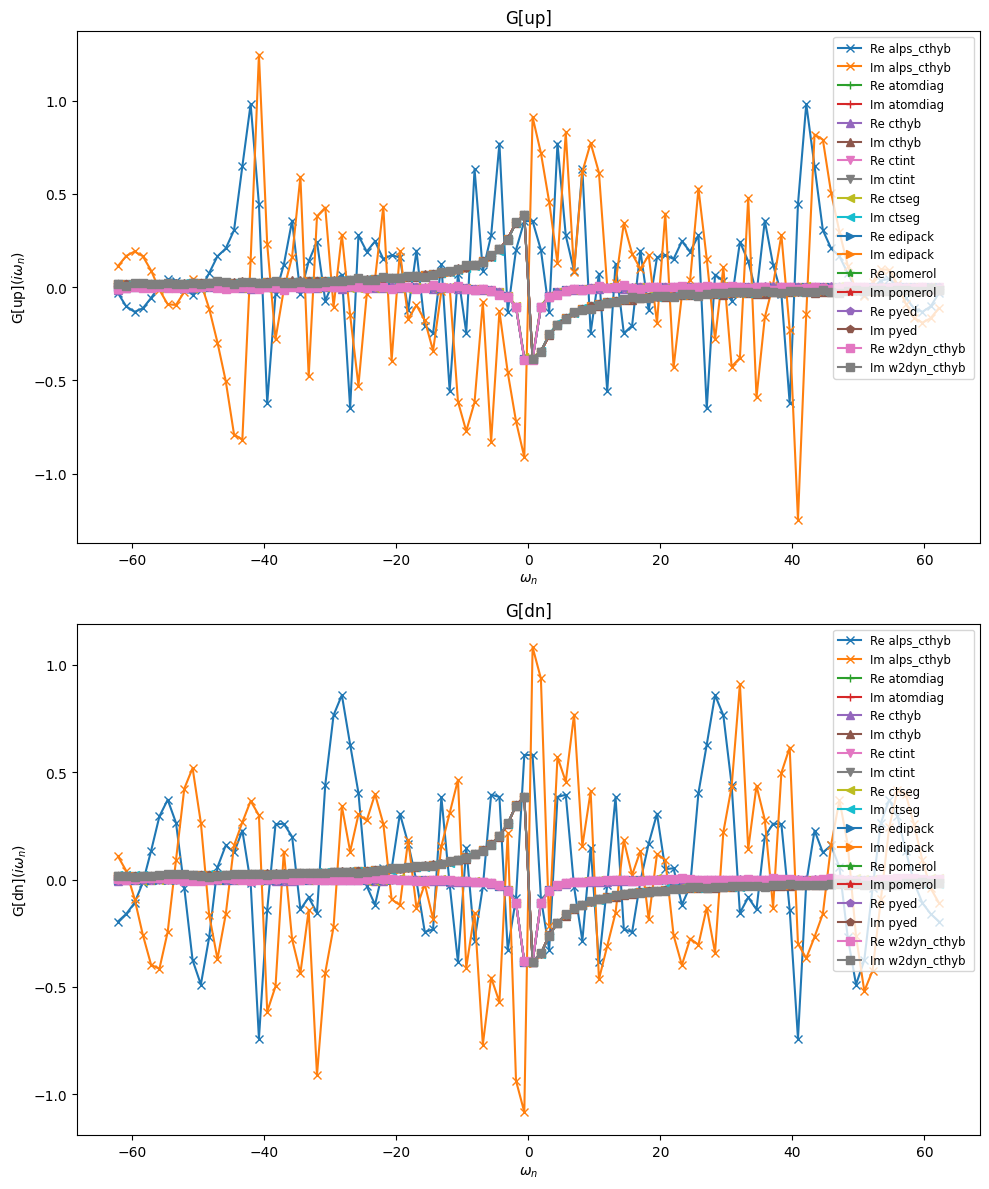

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
                  alps_cthyb     atomdiag        cthyb        ctint        ctseg      edipack      pomerol         pyed  w2dyn_cthyb
     alps_cthyb                  9.26e+01     1.48e+02     9.26e+01     1.05e+02     9.26e+01     9.26e+01     9.26e+01     1.98e+02
       atomdiag                               9.35e+01     1.38e-02     4.56e+01     2.48e-03     5.51e-05     1.51e-12     1.46e+02
          cthyb                                            9.35e+01     6.98e+01     9.35e+01     9.35e+01     9.35e+01     1.34e+02
          ctint                                                         4.56e+01     1.41e-02     1.38e-02     1.38e-02     1.46e+02
          ctseg                                                                      4.56e+01     4.56e+01     4.56e+01     1.35e+02
        edipack                                                                                   2.48e-03     2.48e-03     1.46e+02
        pomerol                        

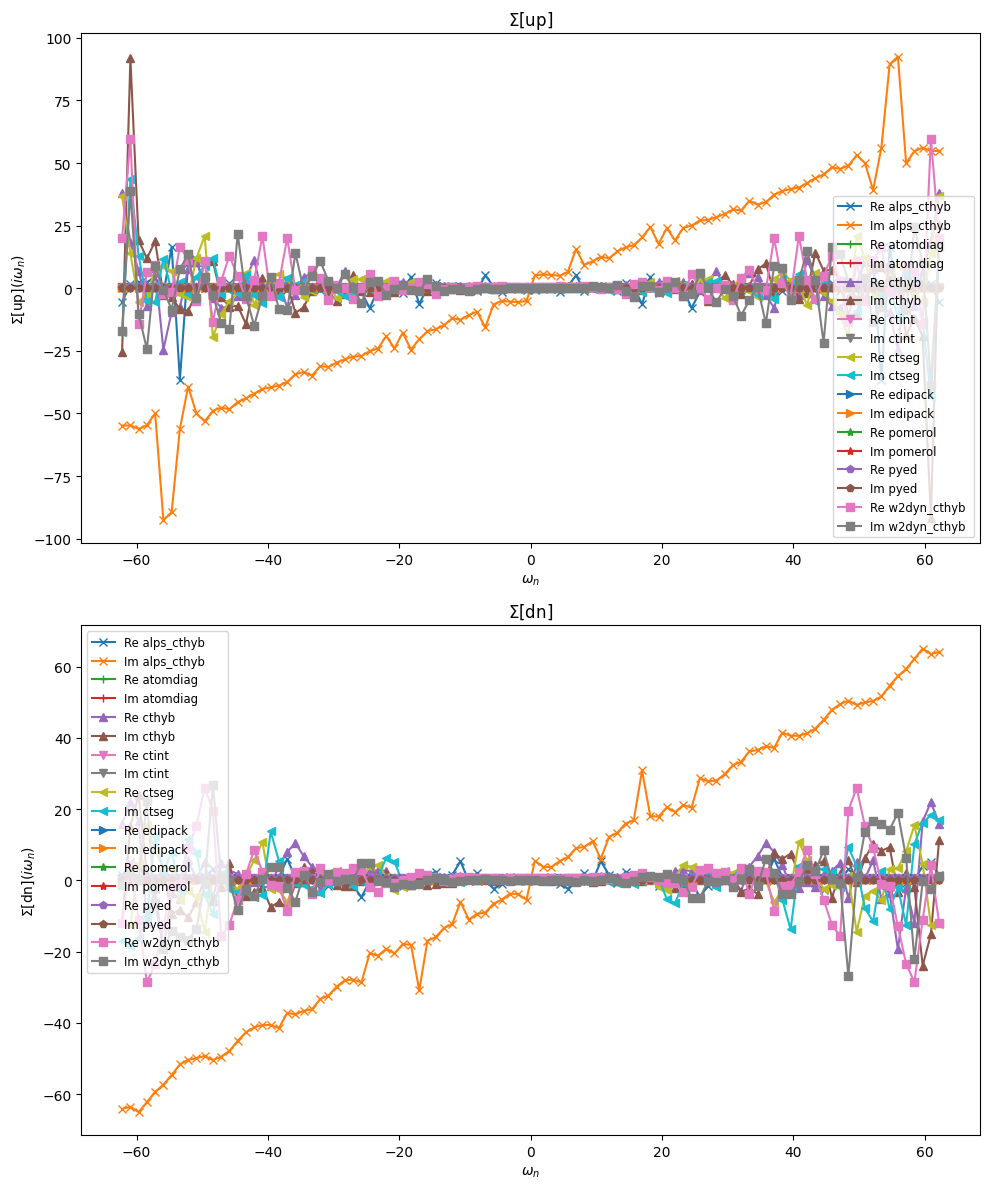

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    atomdiag              dn_0: 0.233189, dn_1: 0.212701, up_0: 0.233189, up_1: 0.212701
    cthyb                 dn_0: 0.233617, dn_1: 0.211985, up_0: 0.233285, up_1: 0.212895
    ctint                 dn_0: 0.233155, dn_1: 0.212866, up_0: 0.233608, up_1: 0.213132
    ctseg                 dn_0: 0.233129, dn_1: 0.212751, up_0: 0.233278, up_1: 0.212564
    edipack               dn_0: 0.232364, dn_1: 0.211893, up_0: 0.232364, up_1: 0.211893
    pomerol               dn_0: 0.233189+0.000000j, dn_1: 0.212701+0.000000j, up_0: 0.233189+0.000000j, up_1: 0.212701+0.000000j
    pyed                  dn_0: 0.233189, dn_1: 0.212701, up_0: 0.233189, up_1: 0.212701

  nn_ab:
    atomdiag              dn_0,dn_0: 0.233189, dn_0,dn_1: 0.005613, dn_0,up_0: 0.049192, dn_0,up_1: 0.044994, dn_1,dn_0: 0.005613, dn_1,dn_1: 0.212701, dn_1,up_0: 0.044994, dn_1,up_1: 0.041146, up_0,dn_0: 0.049192, up_0,dn_1: 0.044994, up_0,up_0: 0.233189, up_0,up_1: 0.005613, up_1,dn_0: 0.044994, up_1,dn_1: 0.041

## 4. Real-Frequency Spectral Function $A(\omega)$

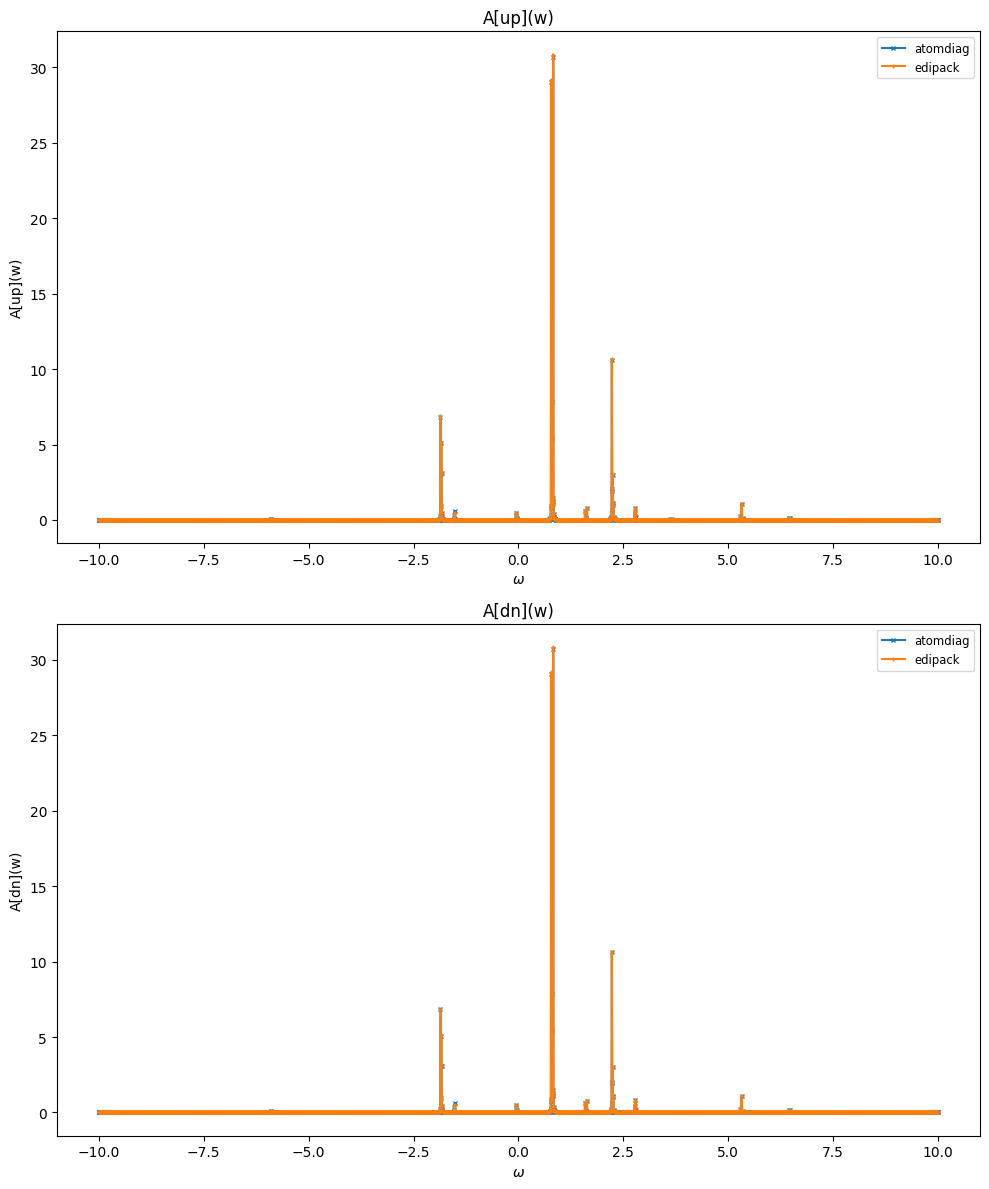

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

## 5. Three-Point Correlator $\chi_3$

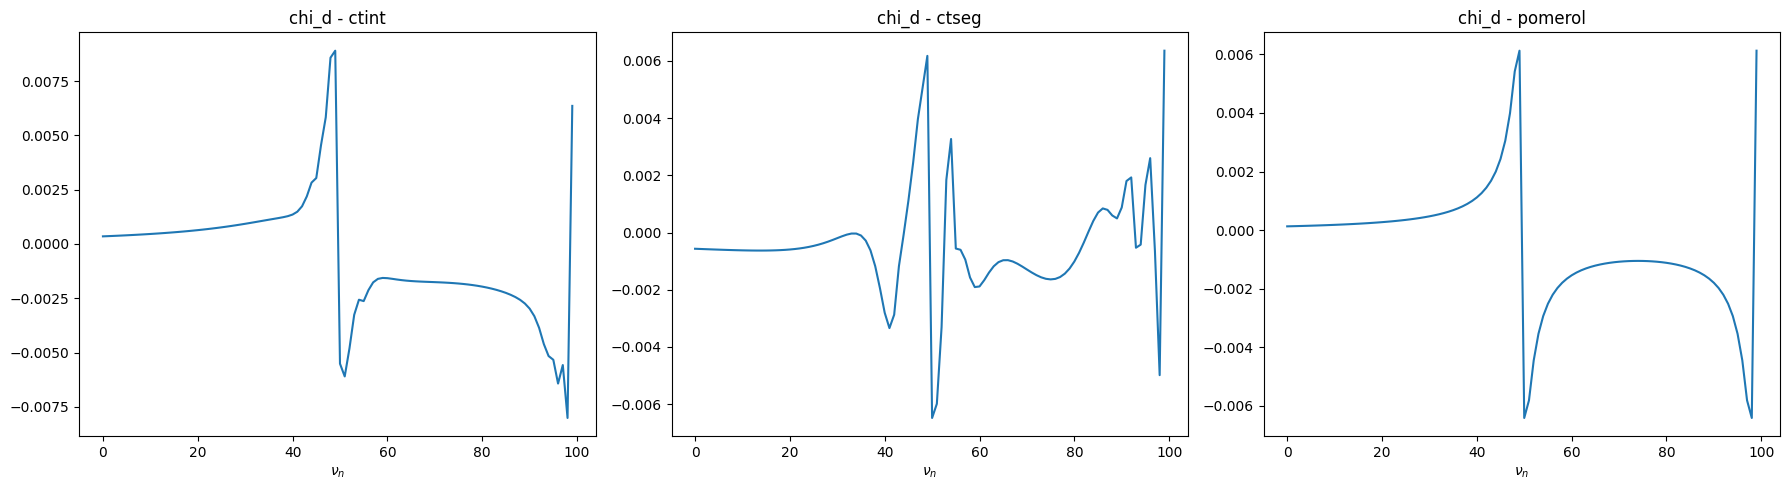

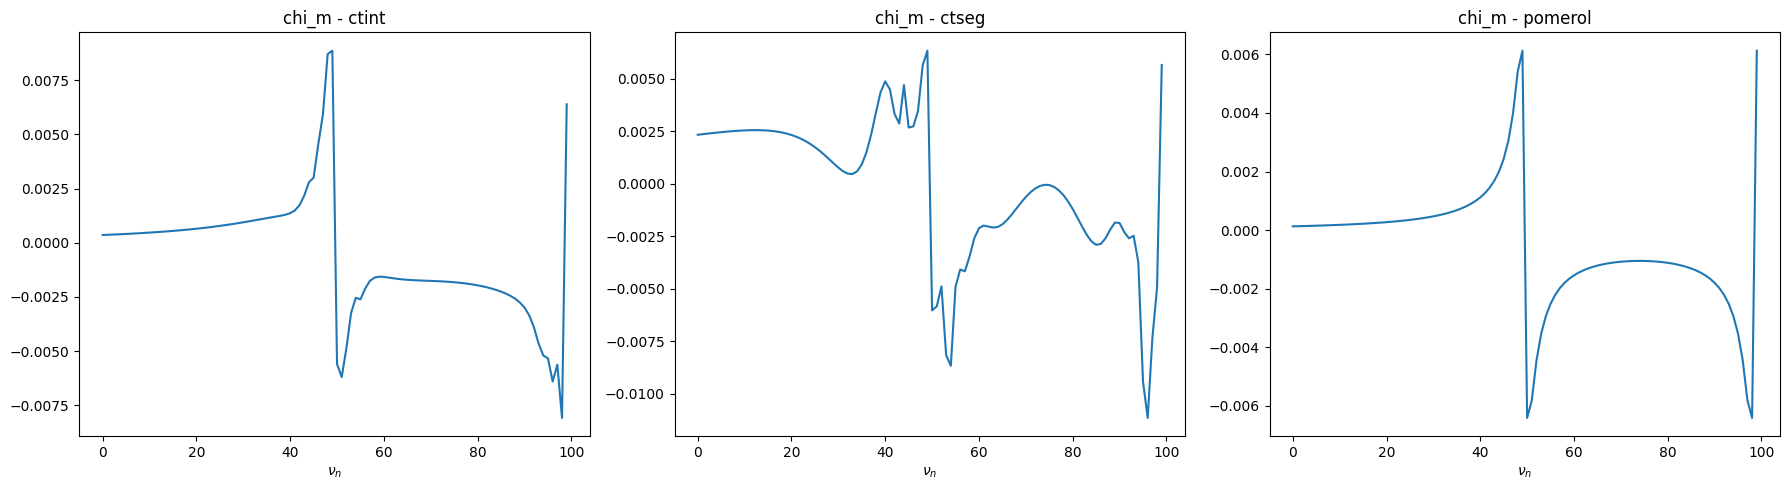

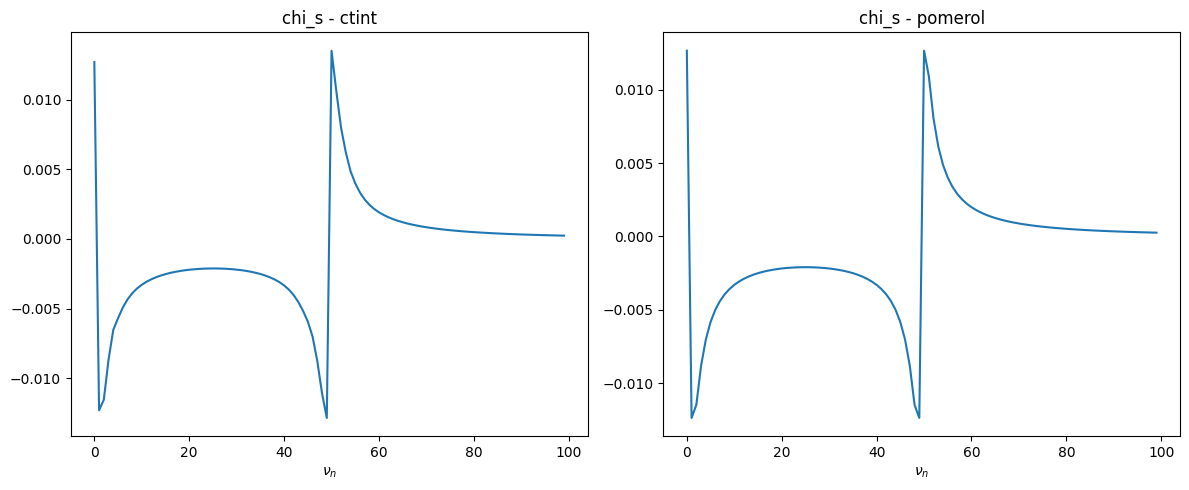

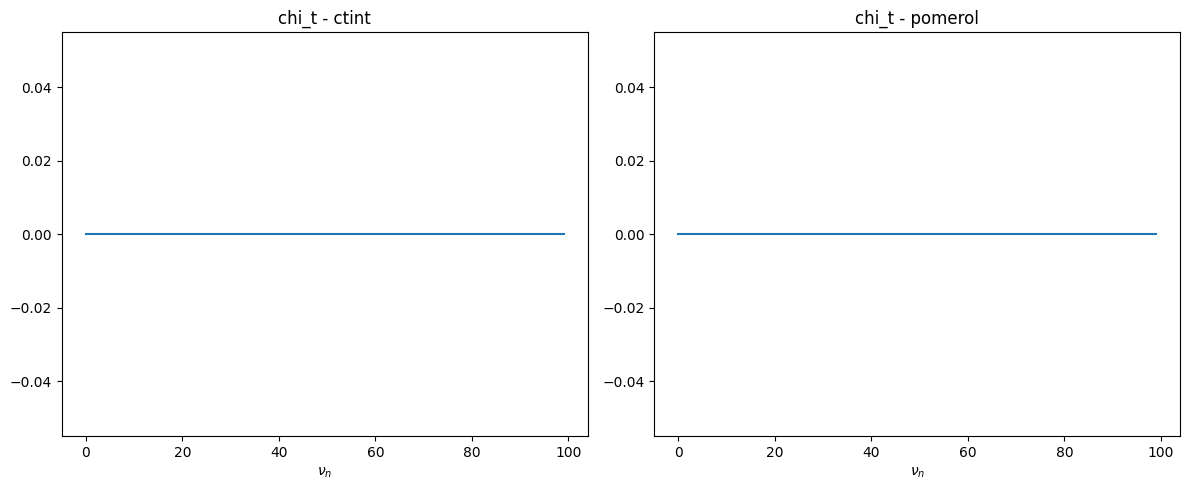

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)